# EDA — Reward Attribution Integrity

Exploratory analysis of the mobile click/attribution data underpinning the fraud
detection system. This notebook runs on whatever `SOURCE_CSV` points at in
`src/config.py` — the synthetic development set by default, the full TalkingData
`train.csv` when available.

**Discipline:** every rate carries a confidence interval, and we never read a
conclusion off a small denominator.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.utils import wilson_ci
from src.evaluate import detectability_floor

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print("Reading:", config.SOURCE_CSV)

Reading: /home/claude/review/data/train_synthetic.csv


## 1. Load with optimised dtypes

TalkingData ships every id as `int64` (8 bytes). The real cardinalities are
small, so we downcast — `ip → uint32`, the rest `uint16`. On the full 200M-row
file this is the difference between fitting on a laptop and not.

Note we do **not** load `attributed_time`: it is non-null exactly when
`is_attributed == 1`, i.e. perfect target leakage.

In [2]:
usecols = ["ip", "app", "device", "os", "channel", "click_time", "is_attributed"]

df = pd.read_csv(config.SOURCE_CSV, usecols=usecols, dtype=config.CSV_DTYPES)
df["click_time"] = pd.to_datetime(df["click_time"], format="ISO8601")   # explicit: robust across pandas versions

# Quantify the saving vs a naive load.
naive = pd.read_csv(config.SOURCE_CSV, usecols=usecols, nrows=len(df))
saving = 1 - df.memory_usage(deep=True).sum() / naive.memory_usage(deep=True).sum()
del naive

print(f"rows: {len(df):,}")
print(f"memory (optimised): {df.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print(f"memory reduction vs naive load: {saving:.0%}")
df.info()

rows: 1,199,738
memory (optimised): 24.0 MB
memory reduction vs naive load: 72%
<class 'pandas.DataFrame'>
RangeIndex: 1199738 entries, 0 to 1199737
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   ip             1199738 non-null  uint32        
 1   app            1199738 non-null  uint16        
 2   device         1199738 non-null  uint16        
 3   os             1199738 non-null  uint16        
 4   channel        1199738 non-null  uint16        
 5   click_time     1199738 non-null  datetime64[us]
 6   is_attributed  1199738 non-null  uint8         
dtypes: datetime64[us](1), uint16(4), uint32(1), uint8(1)
memory usage: 24.0 MB


## 2. Class balance — with a confidence interval, not a bare rate

The first thing to know about any fraud problem is how rare the positive class
is. But a bare proportion on this few positives is misleading, so we attach a
Wilson interval.

In [3]:
n = len(df)
k = int(df["is_attributed"].sum())
rate = k / n
lo, hi = wilson_ci([k], [n])

print(f"conversions (is_attributed=1): {k:,} of {n:,}")
print(f"conversion rate: {rate:.4%}")
print(f"95% Wilson CI: [{lo[0]:.4%}, {hi[0]:.4%}]")
print(f"\nClass imbalance: 1 positive per ~{n/max(k,1):.0f} rows")

conversions (is_attributed=1): 2,083 of 1,199,738
conversion rate: 0.1736%
95% Wilson CI: [0.1663%, 0.1812%]

Class imbalance: 1 positive per ~576 rows


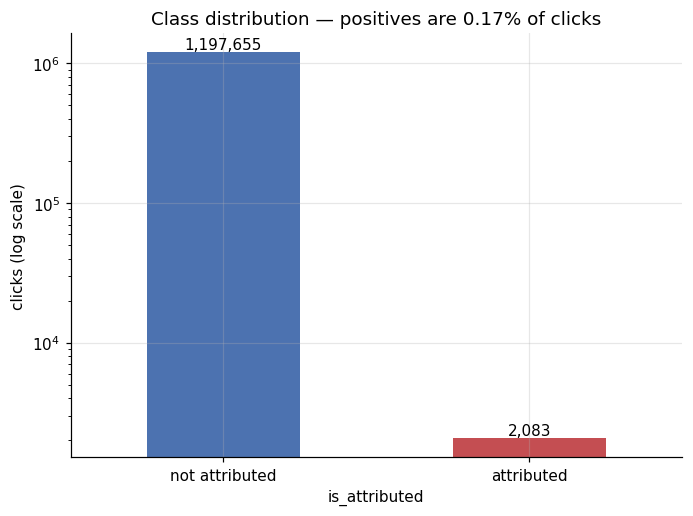

In [4]:
# Log scale, because a linear bar makes the 0.2% positive class invisible.
counts = df["is_attributed"].value_counts().sort_index()
ax = counts.plot(kind="bar", color=["#4c72b0", "#c44e52"], logy=True)
ax.set_xticklabels(["not attributed", "attributed"], rotation=0)
ax.set_ylabel("clicks (log scale)")
ax.set_title(f"Class distribution — positives are {rate:.2%} of clicks")
for i, v in enumerate(counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 3. The leakage trap, demonstrated

`attributed_time` is populated on exactly the converted rows. Any model given it
scores ~100% and learns nothing. We show the trap rather than just assert it.

In [5]:
raw = pd.read_csv(config.SOURCE_CSV, nrows=200_000)
if "attributed_time" in raw.columns:
    ct = pd.crosstab(raw["is_attributed"], raw["attributed_time"].notna(),
                     rownames=["is_attributed"], colnames=["attributed_time present"])
    print(ct)
    print("\n-> attributed_time is present iff is_attributed == 1. Perfect leakage.")
else:
    print("attributed_time not in this file (synthetic set omits it).")
del raw

attributed_time present   False  True 
is_attributed                         
0                        199679      0
1                             0    321

-> attributed_time is present iff is_attributed == 1. Perfect leakage.


## 4. The detectability floor

If an entity converts at the baseline rate *p*, seeing zero conversions in *n*
clicks has probability (1−p)^n. Setting that equal to 0.05 and solving gives the
click count below which "zero conversions" is **not** statistically surprising.

This single number governs the whole evaluation: below it, a suspicious entity
is *unproven*, not guilty.

In [6]:
floor = detectability_floor(rate)
print(f"baseline rate: {rate:.4%}")
print(f"detectability floor: {floor:,} clicks")
print(f"\nBelow ~{floor:,} clicks, a zero-conversion entity cannot be proven")
print("fraudulent from its own record alone.")

baseline rate: 0.1736%
detectability floor: 1,724 clicks

Below ~1,724 clicks, a zero-conversion entity cannot be proven
fraudulent from its own record alone.


## 5. Entity-level view — where the fraud actually lives

Fraud is a property of an actor, not a click. We aggregate to the IP and look
for the fingerprint: **high click volume, near-zero conversion.**

In [7]:
ent = (df.groupby("ip")
         .agg(n_clicks=("is_attributed", "size"),
              n_conv=("is_attributed", "sum"))
         .reset_index())
ent["conv_rate"] = ent["n_conv"] / ent["n_clicks"]
ent = ent[ent["n_clicks"] >= 30]

print(f"entities (>=30 clicks): {len(ent):,}")
print(ent.sort_values("n_clicks", ascending=False).head(10).to_string(index=False))

entities (>=30 clicks): 19,203
    ip  n_clicks  n_conv  conv_rate
500039     11842       0   0.000000
500011     11778       2   0.000170
500021     11628       0   0.000000
500022     11198       1   0.000089
500031     11089       1   0.000090
500000     10699       2   0.000187
500033     10610       0   0.000000
500032     10500       1   0.000095
500024     10336       0   0.000000
500037      9958       1   0.000100


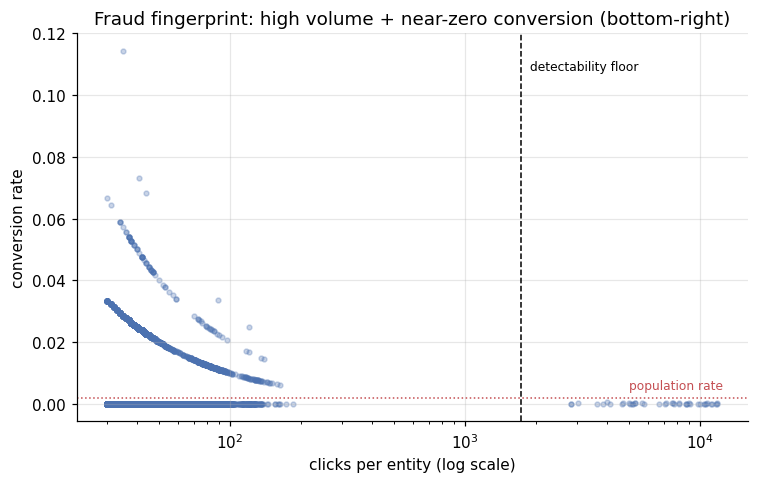

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(ent["n_clicks"], ent["conv_rate"], s=10, alpha=0.3, color="#4c72b0")
ax.axvline(floor, ls="--", color="black", lw=1)
ax.axhline(rate, ls=":", color="#c44e52", lw=1)
ax.annotate("detectability floor", (floor, ax.get_ylim()[1]*0.9),
            textcoords="offset points", xytext=(6, 0), fontsize=8)
ax.annotate("population rate", (ax.get_xlim()[1]*0.4, rate),
            textcoords="offset points", xytext=(0, 6), fontsize=8, color="#c44e52")
ax.set_xscale("log")
ax.set_xlabel("clicks per entity (log scale)")
ax.set_ylabel("conversion rate")
ax.set_title("Fraud fingerprint: high volume + near-zero conversion (bottom-right)")
plt.tight_layout(); plt.show()

## 6. The money chart — timing signature of fraud vs normal

The single most discriminative behaviour is inter-arrival regularity. A human
clicks irregularly; a script fires at near-constant intervals. Here we contrast
the highest-volume entity against a typical one.

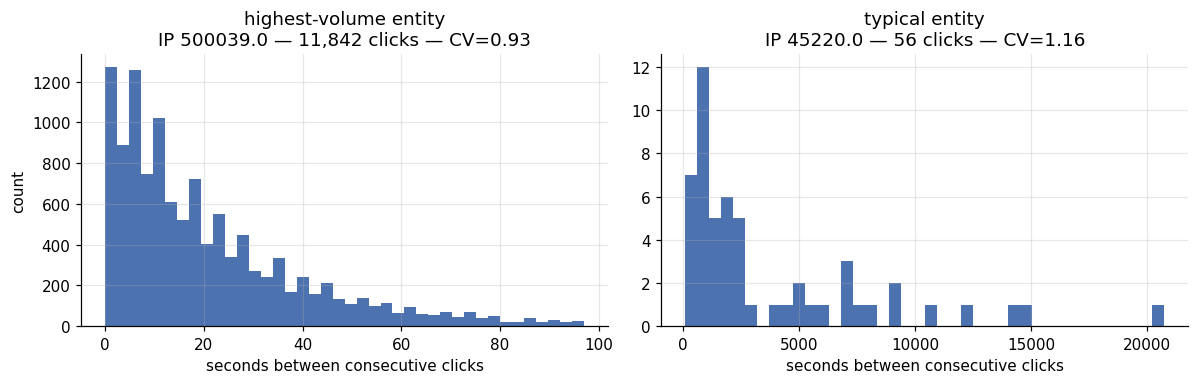

Low coefficient of variation (CV) = metronomic = scripted. Humans sit near 1+.


In [9]:
top_ip = ent.sort_values("n_clicks", ascending=False).iloc[0]["ip"]
mid = ent[(ent["n_clicks"] > 50) & (ent["n_clicks"] < 200)]
normal_ip = mid.iloc[len(mid)//2]["ip"] if len(mid) else ent.iloc[0]["ip"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
for ax, ip, label in [(axes[0], top_ip, "highest-volume entity"),
                      (axes[1], normal_ip, "typical entity")]:
    t = df.loc[df["ip"] == ip, "click_time"].sort_values()
    gaps = t.diff().dt.total_seconds().dropna()
    gaps = gaps[gaps < gaps.quantile(0.99)] if len(gaps) > 10 else gaps
    ax.hist(gaps, bins=40, color="#4c72b0")
    cv = gaps.std() / gaps.mean() if gaps.mean() else float("nan")
    ax.set_title(f"{label}\nIP {ip} — {len(t):,} clicks — CV={cv:.2f}")
    ax.set_xlabel("seconds between consecutive clicks")
axes[0].set_ylabel("count")
plt.tight_layout(); plt.show()
print("Low coefficient of variation (CV) = metronomic = scripted. Humans sit near 1+.")

## Summary

- Positive class is ~0.2% — extreme imbalance, quantified with a CI rather than a bare rate.
- `attributed_time` is a perfect-leakage column and is excluded everywhere.
- The detectability floor (~1,760 clicks at this base rate) bounds what any per-entity
  evaluation can prove, and drives the evidence gate in the detector.
- The fraud fingerprint is high volume + near-zero conversion, with a low-CV
  (metronomic) timing signature.

Next: `src/pipeline.py` builds these entity features at scale and runs the three
detectors. See `docs/analysis_writeup.md` for results.